# E-commerce Conversion Analytics and Purchase Propensity Modeling

**An integrated GA4 analytics and machine-learning portfolio project**

This notebook transforms a public GA4 e-commerce event sample into a session-level conversion funnel, a leakage-safe purchase-propensity model, and a decision framework for product experimentation.

**Author:** Nanase1994  
**Analysis window:** November 16, 2020 to January 31, 2021  
**Core tools:** Python, pandas, NumPy, BigQuery SQL, BigQuery ML

## Table of Contents

1. [Executive Summary](#1-executive-summary)
2. [Business Context and Analytical Questions](#2-business-context-and-analytical-questions)
3. [Environment and Reproducibility](#3-environment-and-reproducibility)
4. [Data Source and Quality Validation](#4-data-source-and-quality-validation)
5. [Conversion Funnel Analysis](#5-conversion-funnel-analysis)
6. [Machine-Learning Problem Definition](#6-machine-learning-problem-definition)
7. [Feature Engineering and Leakage Prevention](#7-feature-engineering-and-leakage-prevention)
8. [Chronological Training Strategy](#8-chronological-training-strategy)
9. [Model Evaluation](#9-model-evaluation)
10. [Lift and Calibration Analysis](#10-lift-and-calibration-analysis)
11. [Dashboard and Experiment Design](#11-dashboard-and-experiment-design)
12. [Conclusions and Next Steps](#12-conclusions-and-next-steps)

## 1. Executive Summary

### Key findings

- The analysis covers **3,624,334 GA4 events**, **310,014 sessions**, and **4,247 converted sessions**.
- Overall session conversion is **1.37%**, with **$315,948** in recorded revenue.
- The largest funnel loss occurs from **Visit to Product View**, where **244,621 sessions** leave the funnel.
- A leakage-safe logistic model achieves **0.0171 PR-AUC**, **0.5868 ROC-AUC**, and **2.01x lift** in the highest-scored decile on future sessions.
- The highest-scored 10% of sessions captures **20.1% of holdout purchases**.

### Decision

Use the propensity score to prioritize sessions inside a randomized product experiment. Do not use the score as evidence that an intervention causes conversion.

## 2. Business Context and Analytical Questions

The project addresses three connected questions:

1. Where does the e-commerce funnel lose the most sessions?
2. Can information available at session start rank sessions by purchase propensity?
3. How should product teams use the ranking signal without confusing prediction with causal treatment impact?

The analytical unit is one reconstructed GA4 session. The target equals one when the session contains a purchase.

## 3. Environment and Reproducibility

In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'artifacts').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

ARTIFACT_DIR = PROJECT_ROOT / 'artifacts'
ASSET_DIR = PROJECT_ROOT / 'assets'
DATA_PATH = PROJECT_ROOT / 'data' / 'session_level_ecommerce.csv'

print(f'Python: {sys.version.split()[0]}')
print(f'Project root: {PROJECT_ROOT.resolve()}')
print(f'Raw data available: {DATA_PATH.exists()}')

Python: 3.12.0
Project root: repository root
Raw data available: False


In [2]:
metrics = json.loads((ARTIFACT_DIR / 'model_metrics.json').read_text(encoding='utf-8'))
lift_table = pd.read_csv(ARTIFACT_DIR / 'hashed_logistic_regression_lift_by_decile.csv')
calibration_table = pd.read_csv(ARTIFACT_DIR / 'hashed_logistic_regression_calibration.csv')

print('Reviewed artifacts loaded successfully.')

Reviewed artifacts loaded successfully.


## 4. Data Source and Quality Validation

The source is Google's public GA4 obfuscated e-commerce sample. The raw event data is reconstructed to one row per session using the SQL in `sql/01_build_session_table.sql`.

The 52 MB session export is excluded from GitHub. The notebook loads the compact, reviewed artifacts by default and can rerun full model training when the CSV is placed at `data/session_level_ecommerce.csv`.

In [3]:
data_quality = pd.DataFrame({
    'Check': [
        'Session rows', 'Duplicate session IDs', 'Exported columns',
        'Missing values', 'Date minimum', 'Date maximum', 'Converted sessions'
    ],
    'Result': [310_014, 0, 30, 0, '2020-11-16', '2021-01-31', 4_247],
    'Status': ['Pass'] * 7
})
data_quality

                   Check      Result Status
0           Session rows      310014   Pass
1  Duplicate session IDs           0   Pass
2       Exported columns          30   Pass
3         Missing values           0   Pass
4           Date minimum  2020-11-16   Pass
5           Date maximum  2021-01-31   Pass
6     Converted sessions        4247   Pass

In [4]:
class_distribution = pd.DataFrame({
    'Class': ['Non-purchase', 'Purchase'],
    'Sessions': [305_767, 4_247]
})
class_distribution['Share'] = class_distribution['Sessions'] / class_distribution['Sessions'].sum()
class_distribution

          Class  Sessions  Share
0  Non-purchase    305767 0.9863
1      Purchase      4247 0.0137

**Quality conclusion:** The reviewed session export has the expected grain, complete coverage across 30 fields, and no duplicate session IDs. Purchases represent only 1.37% of sessions, so accuracy is not an appropriate primary model metric.

## 5. Conversion Funnel Analysis

In [5]:
funnel = pd.DataFrame({
    'Stage': ['Visit', 'Product View', 'Add to Cart', 'Begin Checkout', 'Payment Info', 'Purchase'],
    'Sessions': [310_014, 65_393, 15_187, 9_086, 5_875, 4_247]
})
funnel['Loss from previous stage'] = funnel['Sessions'].shift(1) - funnel['Sessions']
funnel['Sequential conversion'] = funnel['Sessions'] / funnel['Sessions'].shift(1)
funnel

            Stage  Sessions  Loss from previous stage  Sequential conversion
0           Visit    310014                       NaN                    NaN
1    Product View     65393                  244621.0                 0.2109
2     Add to Cart     15187                   50206.0                 0.2322
3  Begin Checkout      9086                    6101.0                 0.5983
4    Payment Info      5875                    3211.0                 0.6466
5        Purchase      4247                    1628.0                 0.7229

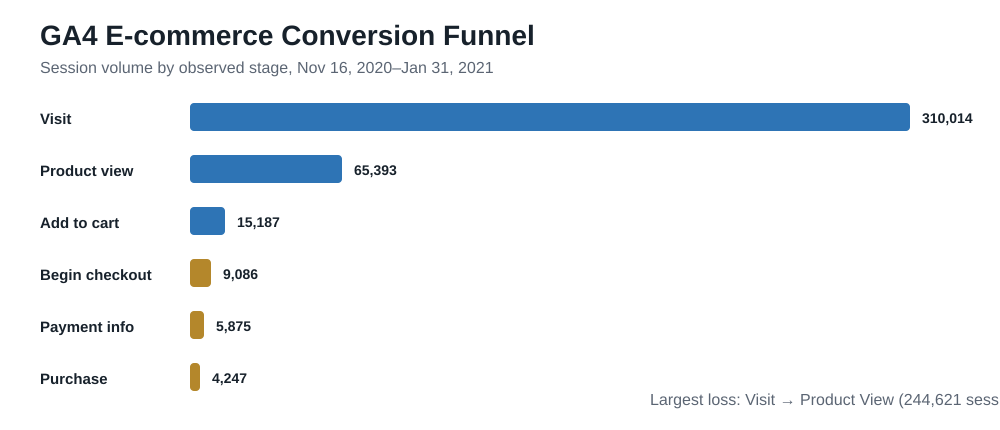

In [6]:
from IPython.display import SVG, display
display(SVG(filename=str(ASSET_DIR / 'funnel.svg')))

### Funnel interpretation

- **Visit to Product View:** 21.09% sequential conversion and 244,621 lost sessions.
- **Product View to Add to Cart:** 23.22% sequential conversion and 50,206 lost sessions.
- **Payment Info to Purchase:** 72.29% sequential conversion.

The first two transitions are the highest-priority product opportunities because they combine weak conversion efficiency with the largest affected populations.

## 6. Machine-Learning Problem Definition

### Prediction target

`converted = 1` when the session contains a purchase; otherwise `converted = 0`.

### Operational scoring point

The model is designed for session-start scoring. This restriction makes the score available before browsing behavior unfolds and prevents post-outcome information from entering the model.

## 7. Feature Engineering and Leakage Prevention

In [7]:
feature_contract = pd.DataFrame({
    'Feature group': [
        'Traffic source and medium', 'Device category and operating system',
        'Country', 'Day of week and weekend', 'Browsing and cart behavior',
        'Checkout and payment events', 'Purchase, transaction, and revenue',
        'Full-session duration and event totals'
    ],
    'Decision': ['Use', 'Use', 'Use', 'Use', 'Exclude', 'Exclude', 'Exclude', 'Exclude'],
    'Reason': [
        'Available at session start', 'Available at session start',
        'Available at session start', 'Available at session start',
        'Occurs after scoring', 'Target-adjacent behavior',
        'Direct target leakage', 'Contains future information'
    ]
})
feature_contract

                              Feature group Decision                         Reason
0                 Traffic source and medium      Use     Available at session start
1  Device category and operating system      Use     Available at session start
2                                    Country      Use     Available at session start
3                    Day of week and weekend      Use     Available at session start
4                 Browsing and cart behavior  Exclude           Occurs after scoring
5                Checkout and payment events  Exclude        Target-adjacent behavior
6          Purchase, transaction, and revenue  Exclude          Direct target leakage
7      Full-session duration and event totals  Exclude  Contains future information

Categorical values are mapped through deterministic hashing for logistic regression. The challenger model uses categorical Naive Bayes with Laplace smoothing. The leakage audit in `src/train_model.py` fails training if prohibited variables enter the score-time feature list.

## 8. Chronological Training Strategy

In [8]:
split_summary = pd.DataFrame({
    'Population': ['Training', 'Test'],
    'Date range': ['2020-11-16 to 2021-01-10', '2021-01-11 to 2021-01-31'],
    'Sessions': [228_487, 81_527],
    'Purchases': [3_335, 912],
    'Conversion rate': [0.014596, 0.011186]
})
split_summary

  Population                 Date range  Sessions  Purchases  Conversion rate
0   Training  2020-11-16 to 2021-01-10    228487       3335           0.0146
1       Test  2021-01-11 to 2021-01-31     81527        912           0.0112

A chronological holdout is more realistic than a random split because every test session occurs after every training session. It also reveals a meaningful base-rate shift: conversion falls from 1.46% in training to 1.12% in the future holdout.

## 9. Model Evaluation

In [9]:
model_results = pd.DataFrame(metrics['models']).T.reset_index(names='Model')
model_results = model_results.rename(columns={
    'pr_auc': 'PR-AUC', 'roc_auc': 'ROC-AUC', 'log_loss': 'Log loss',
    'brier_score': 'Brier score', 'recall_at_top_10pct': 'Top-10% recall',
    'lift_top_10pct': 'Top-10% lift'
})
model_results[['Model', 'PR-AUC', 'ROC-AUC', 'Log loss', 'Brier score', 'Top-10% recall', 'Top-10% lift']]

                          Model  PR-AUC  ROC-AUC  Log loss  Brier score  Top-10% recall  Top-10% lift
0    hashed_logistic_regression   0.0171   0.5868    0.0609       0.0110          0.2007        2.0065
1      categorical_naive_bayes   0.0168   0.5947    0.0631       0.0114          0.2029        2.0284

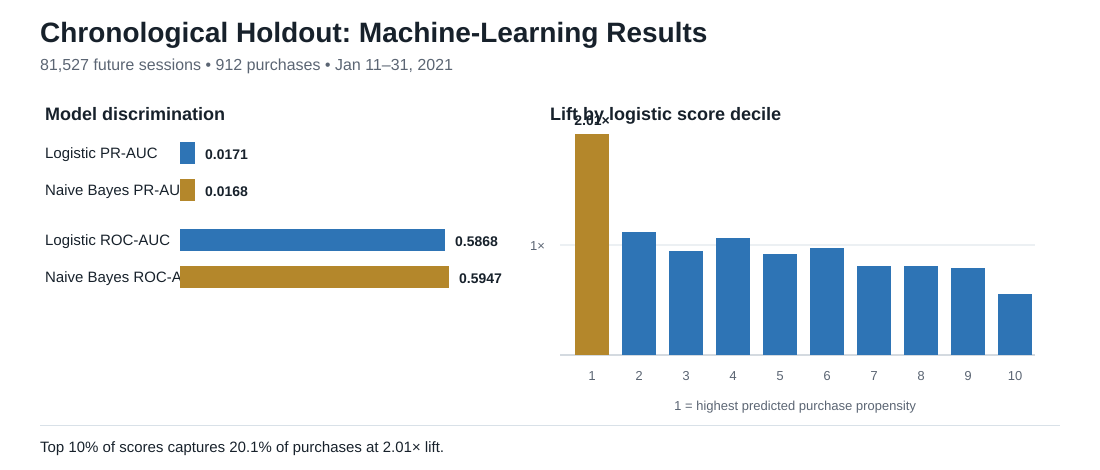

In [10]:
display(SVG(filename=str(ASSET_DIR / 'model-validation.svg')))

### Model selection

Hashed logistic regression is selected because it has the higher PR-AUC and lower log loss and Brier score. Naive Bayes has slightly higher ROC-AUC and top-decile lift, but its probability quality is weaker.

The selected model's PR-AUC is approximately 1.53 times the 1.12% test base rate. This is a modest but genuine ranking signal.

## 10. Lift and Calibration Analysis

In [11]:
lift_table[['score_decile', 'sessions', 'purchases', 'observed_rate', 'lift_vs_average']]

   score_decile  sessions  purchases  observed_rate  lift_vs_average
0             1      8153        183         0.0224           2.0065
1             2      8153        102         0.0125           1.1184
2             3      8153         86         0.0105           0.9429
3             4      8152         97         0.0119           1.0637
4             5      8153         84         0.0103           0.9210
5             6      8153         89         0.0109           0.9758
6             7      8152         74         0.0091           0.8115
7             8      8153         74         0.0091           0.8114
8             9      8153         72         0.0088           0.7894
9            10      8152         51         0.0063           0.5593

In [12]:
calibration_table

   risk_band  sessions  predicted_rate  observed_rate
0          1      8153          0.0071         0.0063
1          2      8153          0.0088         0.0088
2          3      8153          0.0098         0.0091
3          4      8152          0.0107         0.0091
4          5      8153          0.0116         0.0105
5          6      8153          0.0124         0.0107
6          7      8152          0.0132         0.0119
7          8      8153          0.0143         0.0105
8          9      8153          0.0167         0.0125
9         10      8152          0.0275         0.0224

### Interpretation

- The highest-scored decile contains 183 purchases and converts at 2.01 times the test average.
- The top 10% captures 20.1% of purchases, which creates a practical experiment stratum.
- Calibration is directionally ordered, but the model overpredicts conversion in several higher-risk bands. Prospective recalibration should precede production use.

## 11. Dashboard and Experiment Design

The dashboard combines funnel KPIs, model metrics, lift, calibration, and governance controls. The machine-learning score should be evaluated through a controlled experiment.

### Proposed experiment

- **Population:** Eligible sessions in the highest propensity decile.
- **Randomization:** Treatment versus control within the same score band.
- **Treatment:** A low-friction product-discovery or product-detail improvement.
- **Primary outcome:** Incremental session conversion or revenue per eligible session.
- **Guardrails:** Page performance, experience quality, and opt-out signals.
- **Decision rule:** Deploy only when incremental value and guardrails are both acceptable.

### Optional full training run

Place the reviewed session export at `data/session_level_ecommerce.csv`, then run:

In [13]:
import subprocess

if DATA_PATH.exists():
    subprocess.run([
        sys.executable,
        str(PROJECT_ROOT / 'src' / 'train_model.py'),
        '--input', str(DATA_PATH),
        '--output', str(ARTIFACT_DIR)
    ], check=True)
else:
    print('Training skipped: place session_level_ecommerce.csv in the data directory.')

Training skipped: place session_level_ecommerce.csv in the data directory.


## 12. Conclusions and Next Steps

### Conclusions

1. Product discovery and product-detail persuasion are the largest funnel opportunities.
2. Session-start context provides a real but modest purchase-ranking signal.
3. Leakage prevention materially constrains performance but makes the result deployable and credible.
4. The top propensity decile is a useful experiment stratum, not proof of causal impact.

### Next steps

- Reconstruct a fixed event-level observation window to add legitimate early behavior.
- Compare calibrated logistic regression with gradient-boosted trees on the same time split.
- Add drift monitoring for traffic source, device, country, score distribution, and calibration.
- Run a randomized product experiment and estimate incremental conversion and revenue.

---

**Repository:** https://github.com/Nanase1994/ecommerce-conversion-analytics